# Example likelihood calculations for photometric probes (WL, GCph, 2x2pt, and 3x2pt)

Currently implemented only for harmonic-space observables

In [50]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_WL_Cls import EuclidLikelihood_WL_Cls
from cloelike.EuclidLikelihood_GC_Cls import EuclidLikelihood_GC_Cls
from cloelike.EuclidLikelihood_2x2pt_Cls import EuclidLikelihood_2x2pt_Cls
from cloelike.EuclidLikelihood_3x2pt_Cls import EuclidLikelihood_3x2pt_Cls

## Download Synthetic Data

We are currently developing homogeneous synthetic data vectors, mixing matrices, and covariance matrices that are compatible with [euclidlib](https://github.com/euclidlib/euclidlib) and adhere to the data format specifications used by the Euclid Science Ground Segment (LE3).

> ⚠️ This effort is still ongoing. Interfaces and file availability may change as development progresses.


In [ ]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy': 'https://zenodo.org/records/15496892/files/cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy',
        'mixmat_identity_5000_binned.fits': 'https://zenodo.org/records/15496892/files/mixmat_identity_5000_binned.fits',
        'synth_cells_5000_binned.fits': 'https://zenodo.org/records/15496892/files/synth_cells_5000_binned.fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

## Read the Data and Normalise $n(z)$

To begin working with the photometric observables, the first step involves reading the data and normalising the redshift distribution, $n(z)$.

> **Note**: You will need to have installed `euclidlib` version **v2025.2**. Version **v2025.1** is also compatible.

Ensure you have the necessary input files (e.g., redshift distributions, masks, and bias functions) and follow the loading routines provided in the `euclidlib.photo` module.


In [53]:
# Get n(z)
z_nz, nz_heracles = el.photo.redshift_distributions('nz_example.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, myz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, myz)


In [54]:
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
cells_data = el.photo.angular_power_spectra('synth_cells_5000_binned.fits')
mixmat = el.photo.mixing_matrices('mixmat_identity_5000_binned.fits')

# This matrix copies the format of seaborne, that produces a full 3x2pt matrix
full_cov=np.load('cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy')

# Cutting the covariance matrix for each probe
# This should be easier with the new version of euclidlib
cov_WL = full_cov[:(21+21)*32, :(21+21)*32]
cov_GC = full_cov[(21+21+36)*32:, (21+21+36)*32:]
cov_2x2pt = full_cov[(21+21)*32:, (21+21)*32:]

## Prepare Data Dictionary

We envision that the preparation of data will become significantly simpler once a unified format for reading inputs is adopted. This standardised structure will allow for easier integration of synthetic data vectors, mixing matrices, and covariance matrices into the likelihood evaluation pipeline. 


In [56]:
def build_data(ell_key, cov, include_pos=False, include_she=False):
    data = {
        'cells': cells_data,
        'ells': cells_data[ell_key].ell,
        'z_arr': myz,
        'cov': cov,
        'mixmat': mixmat,
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

def build_settings():
    scale_cuts = {key: [10, 1500] for key in cells_data}
    for key in cells_data:
        if key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [scale_cuts[key], [0, 0]]
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

# Build each dataset with correct dndz components
data_WL     = build_data(('SHE', 'SHE', 1, 1), cov_WL,     include_she=True)
data_GC     = build_data(('POS', 'POS', 1, 1), cov_GC,     include_pos=True)
data_2x2pt  = build_data(('POS', 'POS', 1, 1), cov_2x2pt,  include_pos=True, include_she=True)
data_3x2pt  = build_data(('POS', 'POS', 1, 1), full_cov,   include_pos=True, include_she=True)

# Settings (same for all, built from cells_data structure)
settings_WL     = build_settings()
settings_GC     = build_settings()
settings_2x2pt  = build_settings()
settings_3x2pt  = build_settings()

## Likelihood Initialisation

This block handles the initialisation of the Euclid photometric likelihoods in harmonic space. For each observable probe, we construct the corresponding likelihood class instance using the appropriate data and settings dictionaries:

- **WL**: Weak Lensing
- **GC**: Photometric Galaxy Clustering
- **2x2pt**: Joint GC + Galaxy-Galaxy Lensing
- **3x2pt**: Full combination of WL, GC, and GGL

Each likelihood is instantiated with the required cosmological components:
- `CAMBBackground` for background evolution
- `HMemuLinearPerturbations` for linear theory
- `HMemuNonLinearPerturbations` for non-linear corrections

We also time the initialisation process to estimate setup costs for each likelihood. This is particularly useful for understanding performance when running larger parameter scans or MCMC chains.

In [59]:
import time

likelihood_classes = {
    'WL': EuclidLikelihood_WL_Cls,
    'GC': EuclidLikelihood_GC_Cls,
    '2x2pt': EuclidLikelihood_2x2pt_Cls,
    '3x2pt': EuclidLikelihood_3x2pt_Cls,
}

data_dicts = {
    'WL': (data_WL, settings_WL),
    'GC': (data_GC, settings_GC),
    '2x2pt': (data_2x2pt, settings_2x2pt),
    '3x2pt': (data_3x2pt, settings_3x2pt),
}

like_tests = {}
loglike_results = {}

print("🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:")

for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    print(f"\n📊 {label} loglike:")
    data, settings = data_dicts[label]
    cls = likelihood_classes[label]

    start = time.time()
    like_tests[label] = cls(
        data=data,
        settings=settings,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
    )
    end = time.time()

    print(f"⏱️ Time elapsed ({label}): {end - start:.3f} seconds")


🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:

📊 WL loglike:
⏱️ Time elapsed (WL): 0.058 seconds

📊 GC loglike:
⏱️ Time elapsed (GC): 0.055 seconds

📊 2x2pt loglike:
⏱️ Time elapsed (2x2pt): 0.100 seconds

📊 3x2pt loglike:
⏱️ Time elapsed (3x2pt): 0.202 seconds


## Likelihood Evaluation

In this section, we perform a single evaluation of the log-likelihood for each photometric probe at the fiducial cosmological parameters. 

We use a dictionary of initialized likelihood objects (`like_tests`) and evaluate their `loglike()` method using a shared set of default parameters. The execution time for each evaluation is recorded to give a sense of computational cost.

This diagnostic helps verify the setup and responsiveness of the likelihood components for each probe before launching more detailed analyses.


In [60]:
# These are the default parameters used to generate the synthetic data, therefore, the log-likelihood should be close to zero.
default_pars = {'H0':67,'Omega_cdm0':0.27,'Omega_b0':0.049,'ns':0.96,'As':2.1e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.0,'gamma_MG':0.545,
                'log10TAGN': 7.75,
                'AIA':0.16, 'EtaIA':1.66,
                'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414,
                'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0}

In [61]:
# Dictionary of pretty names for output
labels_pretty = {
    'WL': "Weak Lensing (WL)",
    'GC': "Photometric Angular Galaxy Clustering (GC)",
    '2x2pt': "2x2pt (GC + GGL)",
    '3x2pt': "3x2pt"
}

print("⏱️ Timing log-likelihood evaluations and displaying results:")

loglike_results = {}

for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    print(f"\n📊 {labels_pretty[label]} loglike:")
    start = time.time()
    result = like_tests[label].loglike(default_pars)
    elapsed = time.time() - start
    loglike_results[label] = result
    print(f"✅ Returned value ({label}): {result}")
    print(f"⏱️ Time elapsed ({label}): {elapsed:.3f} seconds")


⏱️ Timing log-likelihood evaluations and displaying results:

📊 Weak Lensing (WL) loglike:
✅ Returned value (WL): -1.7563844085995965e-09
⏱️ Time elapsed (WL): 0.140 seconds

📊 Photometric Angular Galaxy Clustering (GC) loglike:
✅ Returned value (GC): -2.456348262212602e-09
⏱️ Time elapsed (GC): 0.438 seconds

📊 2x2pt (GC + GGL) loglike:
✅ Returned value (2x2pt): -5.651043116169738e-09
⏱️ Time elapsed (2x2pt): 0.399 seconds

📊 3x2pt loglike:
✅ Returned value (3x2pt): -9.846737316651602e-09
⏱️ Time elapsed (3x2pt): 0.415 seconds


## Exploring the attributes of loglikelihoods:

This cell shows how to retrieve theory and data vectors as used during the loglike computation.

It also visualizes and compares the masked data and theory vectors for each likelihood (WL, GC, 2x2pt, 3x2pt):

- It creates a 2x4 grid of subplots.
- For each likelihood, it retrieves the masked data vector (`masked_data_vector`) and the masked theory vector (`masked_theory_vector`) from the corresponding likelihood instance in `like_tests`.
- It plots both vectors on a logarithmic y-scale for each probe, using points for the data and a line for the theory.
- Each subplot is labeled with the probe name, and axes are labeled and formatted for clarity.
- The overall figure is titled "Comparison of Masked Data and Theory Vectors for Each Likelihood".

This allows you to visually inspect how well the theory matches the data for each photometric probe after masking and flattening.

/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_36605/3469133200.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10')


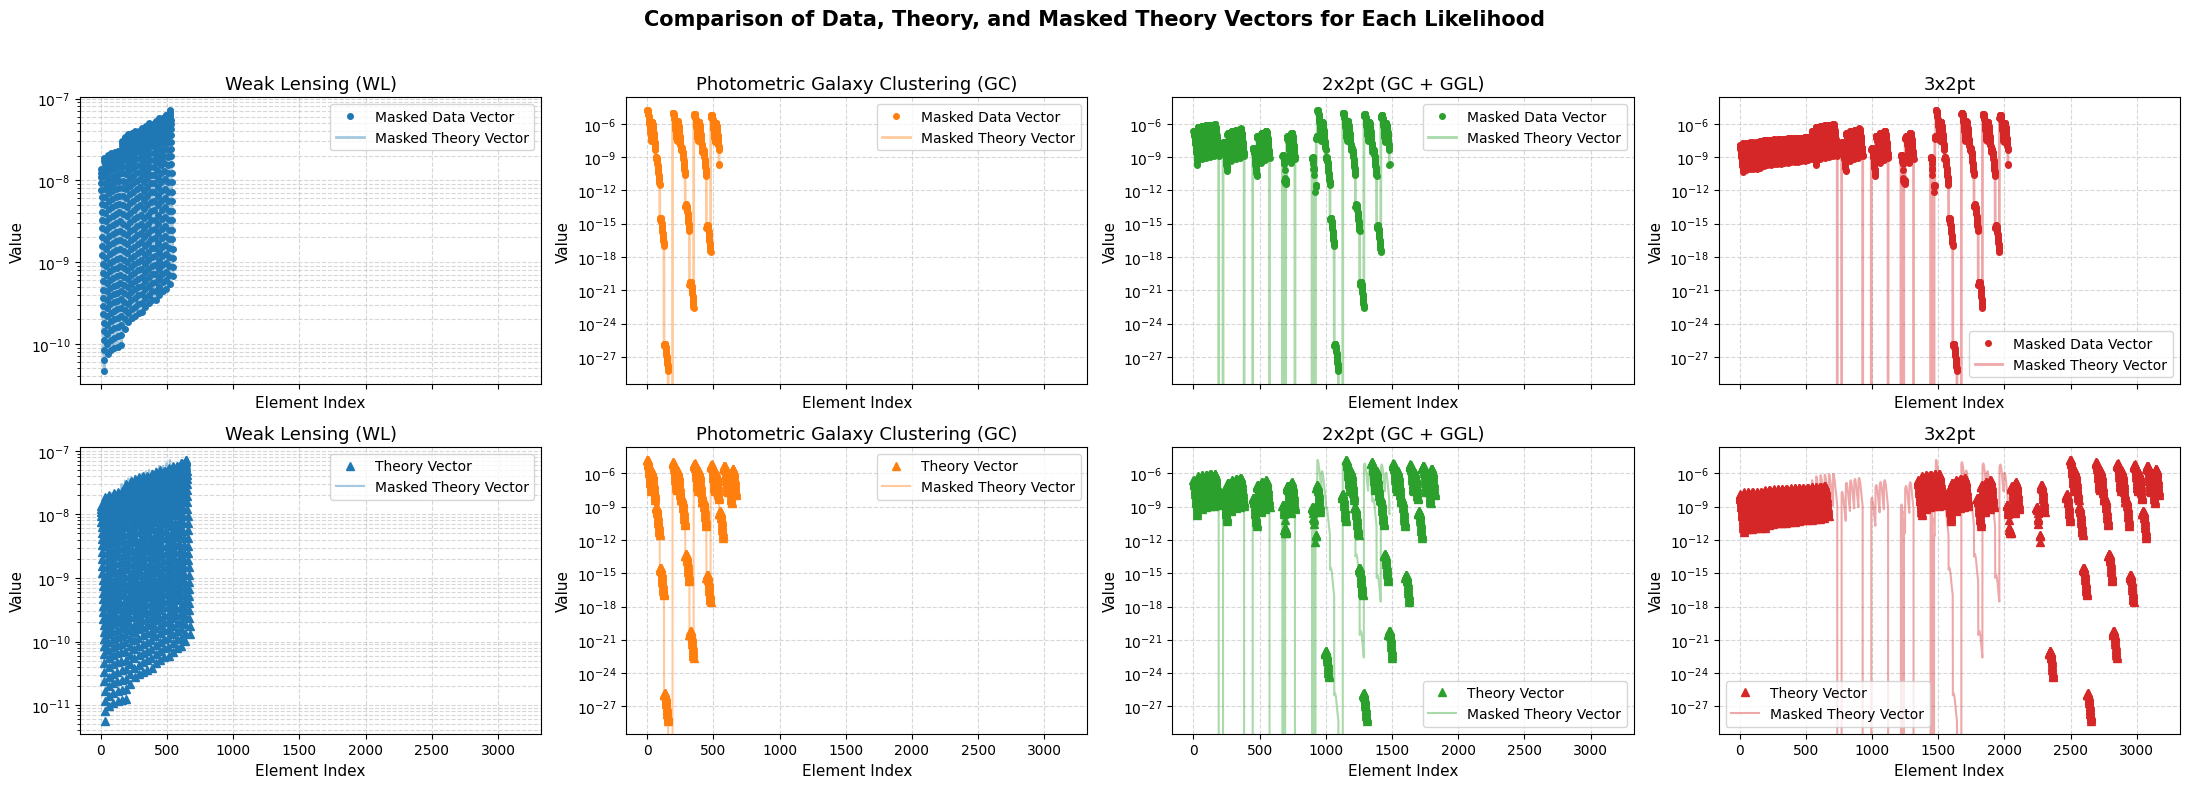

In [78]:
# Access and plot masked data and theory vectors for each likelihood

likelihood_labels = {
    'WL': "Weak Lensing (WL)",
    'GC': "Photometric Galaxy Clustering (GC)",
    '2x2pt': "2x2pt (GC + GGL)",
    '3x2pt': "3x2pt"
}

colors = cm.get_cmap('tab10')

fig, axes = plt.subplots(2, 4, figsize=(22, 8), sharex=True)
axes = axes.flatten()

# Get the maximum length of theory vectors for x-axis
x_theory = {}
for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    theory_vec = getattr(like_tests[label], 'theory_vector', None)
    if theory_vec is not None:
        x_theory[label] = np.arange(len(theory_vec))

for i, label in enumerate(['WL', 'GC', '2x2pt', '3x2pt']):
    # Top: Data vs Masked Theory
    ax = axes[i]
    data_vec = like_tests[label].masked_data_vector
    masked_theory_vec = like_tests[label].masked_theory_vector
    x = x_theory[label]

    ax.semilogy(x[:len(data_vec)], data_vec, 'o', markersize=4, label='Masked Data Vector', color=colors(i))
    ax.semilogy(x[:len(masked_theory_vec)], masked_theory_vec, '-', linewidth=2, label='Masked Theory Vector', color=colors(i), alpha=0.4)
    ax.set_title(likelihood_labels[label], fontsize=13)
    ax.set_xlabel('Element Index', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=10)

    # Bottom: Theory vs Masked Theory
    ax2 = axes[i+4]
    theory_vec = getattr(like_tests[label], 'theory_vector', None)
    if theory_vec is not None:
        ax2.semilogy(x, theory_vec, '^', linewidth=2, label='Theory Vector', color=colors(i), alpha=1.0)
    ax2.semilogy(x[:len(masked_theory_vec)], masked_theory_vec, '-', markersize=4, label='Masked Theory Vector', color=colors(i), alpha=0.4)
    ax2.set_title(f"{likelihood_labels[label]}", fontsize=13)
    ax2.set_xlabel('Element Index', fontsize=11)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.tick_params(axis='both', which='major', labelsize=10)

plt.suptitle('Comparison of Data, Theory, and Masked Theory Vectors for Each Likelihood', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Unflattening the Theory Vector: Making Block Structures Easy!

Ever wondered how to turn the long, flat theory vector back into its original tomographic block structure?  
You can "unflatten" it for clarity—making it much easier to visualize and work with each (i, j) tomographic bin pair.  
This approach helps you inspect, plot, or analyze the spectra for each block directly, instead of dealing with a single long array.

In [ ]:
# Example: Unflatten the theory vector for the 3x2pt likelihood

# Suppose you want to reshape the flat theory vector back to its original block structure.
# You need to know the number of tomographic bins and the number of ell bins per block.

# For illustration, let's assume:
n_tomo = 6  # number of tomographic bins for shear/position
n_ell = 32  # number of ell bins per block (from settings_3x2pt['n_ell_bins'])

# For a block (i, j), the corresponding slice in the flat vector is:
# idx_start = (block_index) * n_ell
# idx_end = idx_start + n_ell

# Let's reconstruct a 2D array for the (i, j) blocks for ('POS', 'POS') as an example:
theory_vec = like_tests['3x2pt'].theory_vector

# Example: Unflatten the ('POS', 'POS') block (first n_tomo x n_tomo blocks)
theory_vec_unflattened = np.zeros((n_tomo, n_tomo, n_ell))
offset = 0
for i in range(n_tomo):
    for j in range(i, n_tomo):
        theory_vec_unflattened[i, j, :] = theory_vec[offset:offset + n_ell]
        offset += n_ell

# Now, theory_vec_unflattened[i, j, :] contains the ell spectrum for tomographic bin pair (i, j) and it is a matrix
print("Shape of unflattened theory block:", theory_vec_unflattened.shape)

Shape of unflattened theory block: (6, 6, 32)


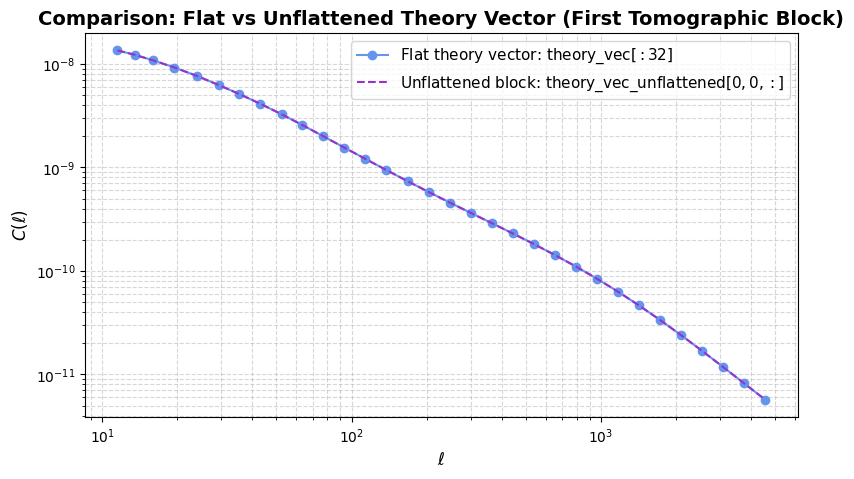

In [80]:
# Plot comparison between the first 32 elements of the flat theory vector and the unflattened (0,0) block
plt.figure(figsize=(8, 5))

plt.plot(cells_data[('POS', 'POS', 1, 1)].ell[:n_ell],
    theory_vec[:n_ell], 
    label=r'Flat theory vector: $\mathrm{theory\_vec}[:32]$', 
    marker='o', 
    color='cornflowerblue',    
    markersize=6
)
plt.plot(cells_data[('POS', 'POS', 1, 1)].ell,
    theory_vec_unflattened[0, 0, :], 
    label=r'Unflattened block: $\mathrm{theory\_vec\_unflattened}[0,0,:]$', 
    linestyle='--', 
    color='darkorchid',
    markersize=6
)

plt.xlabel(r'$\ell$', fontsize=12)
plt.ylabel(r'$C(\ell)$', fontsize=12)
plt.title('Comparison: Flat vs Unflattened Theory Vector (First Tomographic Block)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.show()

## Exploring the Parameter Space

This section illustrates how we explore the dependence of photometric observables on the cold dark matter density parameter, $\Omega_{\rm cdm} h^2$. We scan a range of values and evaluate the likelihood for each photometric probe: Weak Lensing (WL), Galaxy Clustering (GC), 2x2pt (GC + GGL), and 3x2pt.

The likelihoods are computed using the corresponding Euclid likelihood classes, and we normalize each resulting curve to its maximum value for easier visual comparison. A vertical dashed line indicates a fiducial $\Omega_{\rm cdm} h^2$ value (e.g., the best fit).

We use `tqdm` to visually track the progress of likelihood evaluations for each probe.


🔄 Scanning over $\Omega_{cdm} h^2$ for WL


WL: 100%|█████████████████████████████████████| 200/200 [00:26<00:00,  7.61it/s]



🔄 Scanning over $\Omega_{cdm} h^2$ for GC


GC: 100%|█████████████████████████████████████| 200/200 [01:10<00:00,  2.86it/s]



🔄 Scanning over $\Omega_{cdm} h^2$ for 2x2pt


2x2pt: 100%|██████████████████████████████████| 200/200 [01:23<00:00,  2.40it/s]



🔄 Scanning over $\Omega_{cdm} h^2$ for 3x2pt


3x2pt: 100%|██████████████████████████████████| 200/200 [01:32<00:00,  2.17it/s]


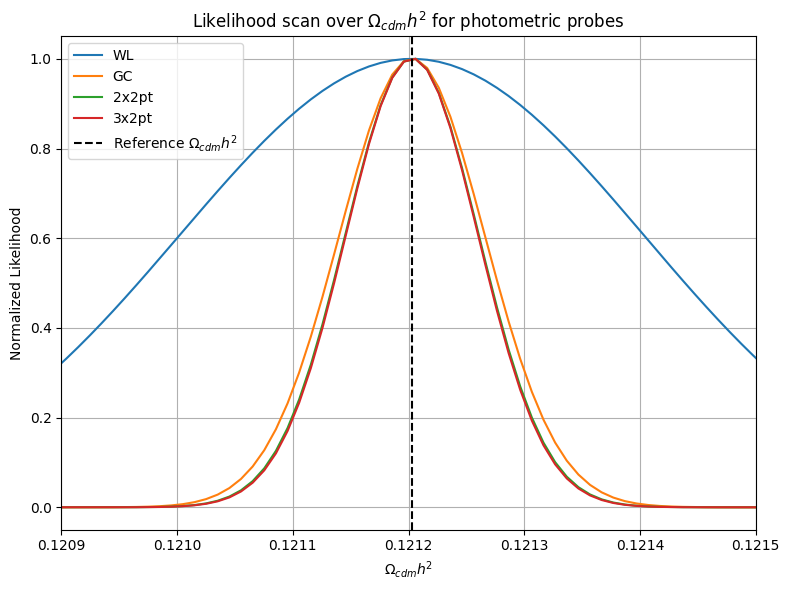

In [10]:
## Exploration of the parameter space
from tqdm import tqdm

# Define the range of Omega_cdm0 values to scan
omch2_vals = np.linspace(0.12, 0.1220, 200)

# Prepare the figure
plt.figure(figsize=(8,6))

for label in ['WL', 'GC', '2x2pt', '3x2pt']:
    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")
    likelihood_curve = []

    for omch2 in tqdm(omch2_vals, desc=f"{label}", ncols=80):
        # Update Omega_cdm0 parameter from omch2 and H0
        default_pars['Omega_cdm0'] = omch2 / (default_pars['H0'] / 100.0)**2

        # Compute log-likelihood
        ll = like_tests[label].loglike(default_pars)
        likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
    plt.plot(omch2_vals, likelihood_curve, label=label)

# Reference vertical line (e.g. Planck best-fit)
plt.axvline(0.27 * 0.67**2, color='k', linestyle='--', label='Reference $\Omega_{cdm} h^2$')

plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\Omega_{cdm} h^2$ for photometric probes')
plt.legend()
plt.xlim([0.1209, 0.1215])
plt.grid(True)
plt.tight_layout()
plt.show()
